# 03 - Basket Option Delta Hedging Backtest

This notebook adds the hedging layer to the project.

It uses the synthetic market inputs from notebook 01 and studies terminal hedged P&L under three strategies:

- `Unhedged short option`: sell the option and invest the premium,
- `Constant-correlation hedge`: compute deltas under the misspecified constant-correlation model,
- `Regime-switching hedge`: compute deltas under the correctly specified regime-switching model.

The true world is a regime-switching correlation model. The goal is to measure how much hedging quality deteriorates when the hedge model ignores correlation regime shifts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

In [2]:
base_dir = Path.cwd()
repo_root = base_dir.parent if base_dir.name == "notebooks" else base_dir
data_dir = repo_root / "data" / "synthetic"

required_files = [
    data_dir / "synthetic_market_data.npz",
    data_dir / "asset_parameters.csv",
    data_dir / "market_settings.csv",
]
missing = [path for path in required_files if not path.exists()]
if missing:
    missing_text = "\n".join(str(path) for path in missing)
    raise FileNotFoundError(
        "Notebook 01 must be executed before running this notebook. Missing files:\n"
        f"{missing_text}"
    )

bundle = np.load(data_dir / "synthetic_market_data.npz")
asset_parameters = pd.read_csv(data_dir / "asset_parameters.csv", index_col=0)
market_settings = pd.read_csv(data_dir / "market_settings.csv", index_col=0).iloc[:, 0]

asset_names = bundle["asset_names"].tolist()
spot = bundle["spot"]
weights = bundle["weights"]
vol = bundle["vol"]
div_yield = bundle["div_yield"]
rate = float(bundle["rate"])
maturity = float(bundle["maturity"])
daily_steps = int(bundle["steps"])
rho_constant = bundle["corr_constant"]
rho_calm = bundle["corr_calm"]
rho_stress = bundle["corr_stress"]
p01_daily = float(bundle["p01"])
p10_daily = float(bundle["p10"])
start_regime = int(bundle["start_regime"])

initial_basket = float(weights @ spot)
strike = initial_basket

display(asset_parameters)
display(market_settings.to_frame(name="value"))
print(f"ATM strike used in the hedging experiment: {strike:.4f}")

,spot,weight,volatility,dividend_yield
Asset 1,100.0,0.40,0.20,0.0
Asset 2,95.0,0.35,0.25,0.0
Asset 3,110.0,0.25,0.22,0.0


,value
risk_free_rate,0.03
maturity_years,1.00
time_steps,252.00
monte_carlo_paths,3000.00
rho_constant,0.35
rho_calm,0.20
rho_stress,0.75
p01,0.03
p10,0.12


ATM strike used in the hedging experiment: 100.7500


## Hedging Grid

The original synthetic market setup was built on a daily grid with 252 steps. For the backtest we rebalance monthly, so the regime transition matrix is aggregated from the daily Markov chain to the monthly hedge step using a matrix power. This keeps the hedging experiment aligned with the original model inputs while staying computationally manageable.

In [3]:
hedge_steps = 12
days_per_hedge_step = daily_steps // hedge_steps
hedge_dt = maturity / hedge_steps

n_true_world_paths = 250
delta_mc_paths = 2000
initial_price_mc_paths = 20000
bump_fraction = 0.01

transition_daily = np.array(
    [
        [1.0 - p01_daily, p01_daily],
        [p10_daily, 1.0 - p10_daily],
    ]
)
transition_hedge = np.linalg.matrix_power(transition_daily, days_per_hedge_step)
p01_hedge = transition_hedge[0, 1]
p10_hedge = transition_hedge[1, 0]

chol_constant = np.linalg.cholesky(rho_constant)
chol_calm = np.linalg.cholesky(rho_calm)
chol_stress = np.linalg.cholesky(rho_stress)

hedging_config = pd.Series(
    {
        "hedge_steps": hedge_steps,
        "days_per_hedge_step": days_per_hedge_step,
        "hedge_dt_years": hedge_dt,
        "true_world_paths": n_true_world_paths,
        "delta_mc_paths": delta_mc_paths,
        "initial_price_mc_paths": initial_price_mc_paths,
        "bump_fraction": bump_fraction,
        "p01_daily": p01_daily,
        "p10_daily": p10_daily,
        "p01_hedge": p01_hedge,
        "p10_hedge": p10_hedge,
    },
    name="value",
)

display(hedging_config.to_frame())
display(pd.DataFrame(transition_hedge, index=["Calm", "Stress"], columns=["Next Calm", "Next Stress"]).round(4))

,value
hedge_steps,12.000000
days_per_hedge_step,21.000000
hedge_dt_years,0.083333
true_world_paths,250.000000
delta_mc_paths,2000.000000
initial_price_mc_paths,20000.000000
bump_fraction,0.010000
p01_daily,0.030000
p10_daily,0.120000
p01_hedge,0.193411


,Next Calm,Next Stress
Calm,0.8066,0.1934
Stress,0.7736,0.2264


## Simulation and Valuation Helpers

The hedge uses bump-and-revalue finite differences with common random numbers. Each delta estimate is based on a fresh Monte Carlo valuation at the current state, but the up and down bumps share the same simulated shocks.

In [4]:
def basket_values(prices, weights):
    return prices @ weights


def basket_call_payoff(prices, weights, strike):
    return np.maximum(basket_values(prices, weights) - strike, 0.0)


def maturity_delta(spot, weights, strike):
    basket_level = float(weights @ spot)
    if basket_level > strike:
        return weights.copy()
    if np.isclose(basket_level, strike):
        return 0.5 * weights
    return np.zeros_like(weights)


def correlate_draws(base_draws, regime_states, chol_by_regime):
    correlated = np.empty_like(base_draws)
    for regime_value, chol in chol_by_regime.items():
        mask = regime_states == regime_value
        if np.any(mask):
            correlated[mask] = base_draws[mask] @ chol.T
    return correlated


def advance_regimes(current_regimes, transition_matrix, rng):
    prob_to_stress = transition_matrix[current_regimes, 1]
    draws = rng.random(current_regimes.size)
    return (draws < prob_to_stress).astype(np.int8)


def simulate_true_world_paths(
    spot,
    rate,
    div_yield,
    vol,
    chol_calm,
    chol_stress,
    maturity,
    hedge_steps,
    n_paths,
    transition_matrix,
    start_regime,
    rng,
):
    n_assets = spot.size
    dt = maturity / hedge_steps
    drift = (rate - div_yield - 0.5 * vol ** 2) * dt
    diffusion = vol * np.sqrt(dt)
    chol_by_regime = {0: chol_calm, 1: chol_stress}

    paths = np.empty((n_paths, hedge_steps + 1, n_assets))
    date_regimes = np.empty((n_paths, hedge_steps), dtype=np.int8)
    paths[:, 0, :] = spot

    current_regimes = np.full(n_paths, start_regime, dtype=np.int8)
    for step in range(hedge_steps):
        date_regimes[:, step] = current_regimes
        base_draws = rng.standard_normal((n_paths, n_assets))
        correlated_draws = correlate_draws(base_draws, current_regimes, chol_by_regime)
        log_increment = drift + diffusion * correlated_draws
        paths[:, step + 1, :] = paths[:, step, :] * np.exp(log_increment)

        if step < hedge_steps - 1:
            current_regimes = advance_regimes(current_regimes, transition_matrix, rng)

    return paths, date_regimes


def constant_model_terminal_factors(spot, rate, div_yield, vol, tau, chol_constant, n_samples, rng):
    if tau <= 0.0:
        return np.ones((n_samples, spot.size))

    drift = (rate - div_yield - 0.5 * vol ** 2) * tau
    diffusion = vol * np.sqrt(tau)
    shocks = rng.standard_normal((n_samples, spot.size)) @ chol_constant.T
    return np.exp(drift + diffusion * shocks)


def regime_model_terminal_factors(
    spot,
    rate,
    div_yield,
    vol,
    hedge_dt,
    steps_remaining,
    chol_calm,
    chol_stress,
    transition_matrix,
    start_regime,
    n_samples,
    rng,
):
    if steps_remaining <= 0:
        return np.ones((n_samples, spot.size))

    drift = (rate - div_yield - 0.5 * vol ** 2) * hedge_dt
    diffusion = vol * np.sqrt(hedge_dt)
    chol_by_regime = {0: chol_calm, 1: chol_stress}
    current_regimes = np.full(n_samples, start_regime, dtype=np.int8)
    log_factors = np.zeros((n_samples, spot.size))

    for step in range(steps_remaining):
        base_draws = rng.standard_normal((n_samples, spot.size))
        correlated_draws = correlate_draws(base_draws, current_regimes, chol_by_regime)
        log_factors += drift + diffusion * correlated_draws

        if step < steps_remaining - 1:
            current_regimes = advance_regimes(current_regimes, transition_matrix, rng)

    return np.exp(log_factors)


In [5]:
def price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction):
    terminal_prices = terminal_factors * spot
    discounted_factor = np.exp(-rate * tau)
    payoffs = basket_call_payoff(terminal_prices, weights, strike)
    price = discounted_factor * payoffs.mean()

    bump_sizes = bump_fraction * np.maximum(spot, 1.0)
    deltas = np.empty_like(spot)
    for asset_idx in range(spot.size):
        up_spot = spot[asset_idx] + bump_sizes[asset_idx]
        down_spot = max(spot[asset_idx] - bump_sizes[asset_idx], 1e-8)
        denominator = up_spot - down_spot

        up_terminal = terminal_prices.copy()
        down_terminal = terminal_prices.copy()
        up_terminal[:, asset_idx] = terminal_factors[:, asset_idx] * up_spot
        down_terminal[:, asset_idx] = terminal_factors[:, asset_idx] * down_spot

        up_payoffs = basket_call_payoff(up_terminal, weights, strike)
        down_payoffs = basket_call_payoff(down_terminal, weights, strike)
        deltas[asset_idx] = discounted_factor * (up_payoffs.mean() - down_payoffs.mean()) / denominator

    return price, deltas


def constant_model_price_and_delta(
    spot,
    tau,
    weights,
    strike,
    rate,
    div_yield,
    vol,
    chol_constant,
    n_samples,
    bump_fraction,
    rng,
):
    if tau <= 0.0:
        payoff = float(basket_call_payoff(spot[None, :], weights, strike)[0])
        return payoff, maturity_delta(spot, weights, strike)

    terminal_factors = constant_model_terminal_factors(
        spot=spot,
        rate=rate,
        div_yield=div_yield,
        vol=vol,
        tau=tau,
        chol_constant=chol_constant,
        n_samples=n_samples,
        rng=rng,
    )
    return price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction)


def regime_model_price_and_delta(
    spot,
    steps_remaining,
    current_regime,
    weights,
    strike,
    rate,
    div_yield,
    vol,
    hedge_dt,
    chol_calm,
    chol_stress,
    transition_matrix,
    n_samples,
    bump_fraction,
    rng,
):
    tau = steps_remaining * hedge_dt
    if steps_remaining <= 0:
        payoff = float(basket_call_payoff(spot[None, :], weights, strike)[0])
        return payoff, maturity_delta(spot, weights, strike)

    terminal_factors = regime_model_terminal_factors(
        spot=spot,
        rate=rate,
        div_yield=div_yield,
        vol=vol,
        hedge_dt=hedge_dt,
        steps_remaining=steps_remaining,
        chol_calm=chol_calm,
        chol_stress=chol_stress,
        transition_matrix=transition_matrix,
        start_regime=current_regime,
        n_samples=n_samples,
        rng=rng,
    )
    return price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction)


def pnl_summary(pnl):
    return pd.Series(
        {
            "mean_pnl": pnl.mean(),
            "std_pnl": pnl.std(ddof=1),
            "median_pnl": np.median(pnl),
            "q05_pnl": np.quantile(pnl, 0.05),
            "q01_pnl": np.quantile(pnl, 0.01),
            "min_pnl": pnl.min(),
            "max_pnl": pnl.max(),
        }
    )

## Initial Option Value and Time-0 Deltas

Each strategy starts from its own model price. That means terminal P&L reflects both initial pricing error and dynamic hedge error. In the current setup the two model prices are close, so most of the comparison should come from hedge quality rather than from a large day-0 mispricing.

In [6]:
constant_price_0, constant_delta_0 = constant_model_price_and_delta(
    spot=spot,
    tau=maturity,
    weights=weights,
    strike=strike,
    rate=rate,
    div_yield=div_yield,
    vol=vol,
    chol_constant=chol_constant,
    n_samples=initial_price_mc_paths,
    bump_fraction=bump_fraction,
    rng=np.random.default_rng(1000),
)

regime_price_0, regime_delta_0 = regime_model_price_and_delta(
    spot=spot,
    steps_remaining=hedge_steps,
    current_regime=start_regime,
    weights=weights,
    strike=strike,
    rate=rate,
    div_yield=div_yield,
    vol=vol,
    hedge_dt=hedge_dt,
    chol_calm=chol_calm,
    chol_stress=chol_stress,
    transition_matrix=transition_hedge,
    n_samples=initial_price_mc_paths,
    bump_fraction=bump_fraction,
    rng=np.random.default_rng(2000),
)

initial_hedge_table = pd.DataFrame(
    [
        {
            "strategy": "Constant-correlation hedge",
            "initial_price": constant_price_0,
            **{f"delta_{name}": value for name, value in zip(asset_names, constant_delta_0)},
        },
        {
            "strategy": "Regime-switching hedge",
            "initial_price": regime_price_0,
            **{f"delta_{name}": value for name, value in zip(asset_names, regime_delta_0)},
        },
    ]
).set_index("strategy")

display(initial_hedge_table.round(4))
print(f"Initial price gap (regime - constant): {regime_price_0 - constant_price_0:.4f}")

,initial_price,delta_Asset 1,delta_Asset 2,delta_Asset 3
strategy,,,,
Constant-correlation hedge,8.1836,0.2397,0.2150,0.1497
Regime-switching hedge,8.1489,0.2411,0.2167,0.1505


Initial price gap (regime - constant): -0.0347


## Simulate the True World

In [7]:
true_world_paths, true_world_regimes = simulate_true_world_paths(
    spot=spot,
    rate=rate,
    div_yield=div_yield,
    vol=vol,
    chol_calm=chol_calm,
    chol_stress=chol_stress,
    maturity=maturity,
    hedge_steps=hedge_steps,
    n_paths=n_true_world_paths,
    transition_matrix=transition_hedge,
    start_regime=start_regime,
    rng=np.random.default_rng(3000),
)

stress_fraction_by_path = true_world_regimes.mean(axis=1)
terminal_payoff_true_world = basket_call_payoff(true_world_paths[:, -1, :], weights, strike)

true_world_summary = pd.Series(
    {
        "avg_stress_fraction": stress_fraction_by_path.mean(),
        "median_stress_fraction": np.median(stress_fraction_by_path),
        "mean_terminal_basket": basket_values(true_world_paths[:, -1, :], weights).mean(),
        "mean_terminal_payoff": terminal_payoff_true_world.mean(),
    },
    name="value",
)

display(true_world_summary.to_frame())

,value
avg_stress_fraction,0.195667
median_stress_fraction,0.166667
mean_terminal_basket,102.287902
mean_terminal_payoff,7.371368


In [8]:
def run_delta_hedge_backtest(strategy_name, base_seed):
    if strategy_name == "Unhedged short option":
        terminal_pnl = regime_price_0 * np.exp(rate * maturity) - terminal_payoff_true_world
        return terminal_pnl, regime_price_0, np.zeros_like(spot)

    if strategy_name == "Constant-correlation hedge":
        initial_price = constant_price_0
        initial_delta = constant_delta_0.copy()
    elif strategy_name == "Regime-switching hedge":
        initial_price = regime_price_0
        initial_delta = regime_delta_0.copy()
    else:
        raise ValueError(f"Unknown strategy: {strategy_name}")

    cash_account = np.full(n_true_world_paths, initial_price) - true_world_paths[:, 0, :] @ initial_delta
    delta_holdings = np.tile(initial_delta, (n_true_world_paths, 1))

    for step in range(hedge_steps - 1):
        next_spots = true_world_paths[:, step + 1, :]
        cash_account *= np.exp(rate * hedge_dt)
        portfolio_before_rehedge = cash_account + np.sum(delta_holdings * next_spots, axis=1)
        remaining_steps = hedge_steps - (step + 1)

        new_deltas = np.empty_like(delta_holdings)
        for path_idx in range(n_true_world_paths):
            state_seed = base_seed + step * 10000 + path_idx
            state_rng = np.random.default_rng(state_seed)

            if strategy_name == "Constant-correlation hedge":
                _, state_delta = constant_model_price_and_delta(
                    spot=next_spots[path_idx],
                    tau=remaining_steps * hedge_dt,
                    weights=weights,
                    strike=strike,
                    rate=rate,
                    div_yield=div_yield,
                    vol=vol,
                    chol_constant=chol_constant,
                    n_samples=delta_mc_paths,
                    bump_fraction=bump_fraction,
                    rng=state_rng,
                )
            else:
                _, state_delta = regime_model_price_and_delta(
                    spot=next_spots[path_idx],
                    steps_remaining=remaining_steps,
                    current_regime=int(true_world_regimes[path_idx, step + 1]),
                    weights=weights,
                    strike=strike,
                    rate=rate,
                    div_yield=div_yield,
                    vol=vol,
                    hedge_dt=hedge_dt,
                    chol_calm=chol_calm,
                    chol_stress=chol_stress,
                    transition_matrix=transition_hedge,
                    n_samples=delta_mc_paths,
                    bump_fraction=bump_fraction,
                    rng=state_rng,
                )

            new_deltas[path_idx] = state_delta

        cash_account = portfolio_before_rehedge - np.sum(new_deltas * next_spots, axis=1)
        delta_holdings = new_deltas

    terminal_spots = true_world_paths[:, -1, :]
    cash_account *= np.exp(rate * hedge_dt)
    terminal_pnl = cash_account + np.sum(delta_holdings * terminal_spots, axis=1) - terminal_payoff_true_world
    return terminal_pnl, initial_price, initial_delta


strategy_seeds = {
    "Unhedged short option": 5000,
    "Constant-correlation hedge": 6000,
    "Regime-switching hedge": 7000,
}

strategy_outputs = {}
for strategy_name, seed in strategy_seeds.items():
    strategy_outputs[strategy_name] = run_delta_hedge_backtest(strategy_name, seed)

pathwise_pnl = pd.DataFrame(
    {
        "path_id": np.arange(n_true_world_paths),
        "stress_fraction": stress_fraction_by_path,
        "terminal_payoff": terminal_payoff_true_world,
        "Unhedged short option": strategy_outputs["Unhedged short option"][0],
        "Constant-correlation hedge": strategy_outputs["Constant-correlation hedge"][0],
        "Regime-switching hedge": strategy_outputs["Regime-switching hedge"][0],
    }
)

hedging_summary = pd.DataFrame(
    {
        strategy_name: pnl_summary(result[0])
        for strategy_name, result in strategy_outputs.items()
    }
).T
hedging_summary.index.name = "strategy"
hedging_summary.insert(0, "initial_price", [strategy_outputs[name][1] for name in hedging_summary.index])
hedging_summary.insert(1, "initial_price_diff_vs_regime", hedging_summary["initial_price"] - regime_price_0)
hedging_summary["std_reduction_vs_unhedged"] = 1.0 - hedging_summary["std_pnl"] / hedging_summary.loc["Unhedged short option", "std_pnl"]

display(hedging_summary.round(4))

,initial_price,initial_price_diff_vs_regime,mean_pnl,std_pnl,median_pnl,q05_pnl,q01_pnl,min_pnl,max_pnl,std_reduction_vs_unhedged
strategy,,,,,,,,,,
Unhedged short option,8.1489,0.0000,1.0257,10.5298,6.9498,-19.9531,-33.9802,-44.8178,8.3970,0.0000
Constant-correlation hedge,8.1836,0.0347,0.1495,1.5500,0.1752,-2.1540,-3.9935,-4.8221,4.3637,0.8528
Regime-switching hedge,8.1489,0.0000,0.0898,1.5177,0.0627,-2.1671,-3.8061,-5.0126,4.1614,0.8559


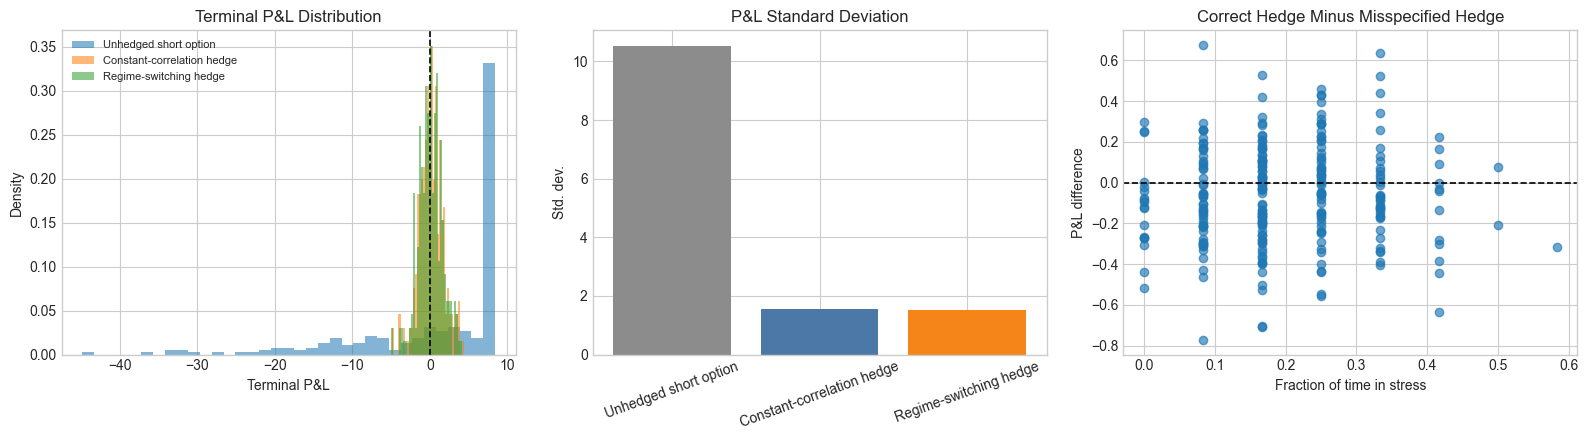

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for strategy_name in ["Unhedged short option", "Constant-correlation hedge", "Regime-switching hedge"]:
    axes[0].hist(pathwise_pnl[strategy_name], bins=35, alpha=0.55, density=True, label=strategy_name)
axes[0].axvline(0.0, color="black", linestyle="--", linewidth=1.2)
axes[0].set_title("Terminal P&L Distribution")
axes[0].set_xlabel("Terminal P&L")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

axes[1].bar(hedging_summary.index, hedging_summary["std_pnl"], color=["#8c8c8c", "#4c78a8", "#f58518"])
axes[1].set_title("P&L Standard Deviation")
axes[1].set_ylabel("Std. dev.")
axes[1].tick_params(axis="x", rotation=20)

axes[2].scatter(
    pathwise_pnl["stress_fraction"],
    pathwise_pnl["Regime-switching hedge"] - pathwise_pnl["Constant-correlation hedge"],
    alpha=0.65,
)
axes[2].axhline(0.0, color="black", linestyle="--", linewidth=1.2)
axes[2].set_title("Correct Hedge Minus Misspecified Hedge")
axes[2].set_xlabel("Fraction of time in stress")
axes[2].set_ylabel("P&L difference")

plt.tight_layout()
plt.show()

The middle panel should show the basic effect of hedging: both hedge strategies should sharply reduce P&L dispersion relative to the unhedged short option. The comparison between the two hedgers is subtler and depends on how often the true world visits the stress regime.

## Persist Hedging Outputs

In [10]:
initial_hedge_table.to_csv(data_dir / "basket_option_initial_hedge_table.csv")
hedging_summary.to_csv(data_dir / "basket_option_hedging_summary.csv")
pathwise_pnl.to_csv(data_dir / "basket_option_hedging_pathwise_pnl.csv", index=False)

print(f"Saved initial hedge table to {data_dir / 'basket_option_initial_hedge_table.csv'}")
print(f"Saved hedging summary to {data_dir / 'basket_option_hedging_summary.csv'}")
print(f"Saved pathwise P&L to {data_dir / 'basket_option_hedging_pathwise_pnl.csv'}")

Saved initial hedge table to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_initial_hedge_table.csv
Saved hedging summary to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_hedging_summary.csv
Saved pathwise P&L to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_hedging_pathwise_pnl.csv
